 # Pointwise Custom-DRAG Analysis



 This notebook separates the expensive pulse construction from the subsequent

 propagation and plotting stages. Once a numerical pulse has been obtained, the

 analysis and visualization cells can be rerun without repeating the pointwise

 optimization.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from qutip import sesolve
from scipy.interpolate import CubicSpline
from scipy.linalg import expm
from tqdm.auto import tqdm

from custom_drag_optimizer_class import CustomDRAGConfig, CustomDRAGOptimizer
from FAPT import Heff_Floquet_total_matrix_summed, W_Floquet_elements_fast
from pulse_optimization import infid_population
from utils import Simulation

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 8.5,
    "lines.linewidth": 1.6,
})


 ## 1. Configuration



 The configuration fixes the perturbative truncation, pulse family, gate time,

 and numerical resolution. Enabling the second harmonic introduces two

 additional quadratures which are used to suppress the effective coupling

 $H_{02}$.

In [ ]:
config = CustomDRAGConfig(
    tg=20.0,
    sigma_r=0.1,
    pulse_type="tanh",       # "gauss" or "tanh"
    drag_order=5,
    rH=2,
    rW=1,
    use_second_harmonic=True,
    run_drag_target_simulation=True,
    N_t=2000,
)

s = Simulation()
result = CustomDRAGOptimizer(s, config)

checkpoint_dir = Path("operational_res/custom_drag")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / (
    f"pointwise_{config.pulse_type}_tg{config.tg:g}_"
    f"Nt{config.N_t}_second{int(config.use_second_harmonic)}.npz"
)


Initial resonance frequency: wd0 = 4.43804329
Base pulse:                  tanh
Second harmonic / H02 cancel: True


 ## 2. Uncorrected reference pulse



 The base envelope is normalized such that the effective $H_{01}$ coupling has

 the requested pulse area. This reference defines $\mathcal{E}_\pi(t)$ and its

 derivative for the time-dependent DRAG target.

In [3]:
result.prepare_base_target()
# f0 = 3.1222706918 für rH=3 rW=2

Base amplitude factor:        f0 = 8.5856313428
Base effective pulse area:    1.5707963268


 ## 3. Pointwise pulse construction



 This is the main expensive stage. At every time point, the drive frequency and

 quadratures are chosen to reproduce the instantaneous DRAG Hamiltonian. If the

 second harmonic is enabled, its two quadratures additionally minimize the real

 and imaginary parts of $H_{02}$.



 Run this cell only when a new pulse has to be generated. Otherwise use the

 checkpoint-loading cell below.

In [4]:
result.optimize_pointwise()


Optimizing custom DRAG pulse: 100%|██████████| 200/200 [00:54<00:00,  3.66it/s]


Pointwise target-matching diagnostics
Normalization scales: H11=6.827e-01, H01/H02=9.117e-02
Max normalized H11     mismatch: 1.448e-01
Max normalized Re(H01) mismatch: 2.350e-01
Max normalized Im(H01) mismatch: 4.094e-02
Max combined target mismatch:     2.388e-01
Max normalized |H02|:             3.266e-02
Max absolute |H02|:               2.978e-03
Mean optimizer objective:         1.144e-02
Max lambda-relation mismatch:     2.386e+01
Max relative lambda variation:    3.037e+00
Max relative Delta variation:     2.962e+00
Max |A2r| / |A2i|:                1.817e+01 / 1.436e+01


 ## 4. Save the pointwise result



 The optimized controls, effective Hamiltonians, targets, and derivative data

 are stored independently of all later propagation and plotting choices.

In [5]:
pointwise_fields = (
    "f0", "base_solutions", "ep0", "ep0_dot",
    "solutions", "control_derivatives",
    "Delta_values", "dDelta_values", "lambda_values",
    "targets", "H_eff_values",
    "optimization_residuals", "total_residuals",
    "core_scales", "H01_scale", "H02_scale",
)

np.savez_compressed(
    checkpoint_path,
    **{name: getattr(result, name) for name in pointwise_fields},
)
print(f"Saved pointwise result to {checkpoint_path}")


Saved pointwise result to operational_res/custom_drag/pointwise_tanh_tg20_Nt200_second1.npz


 ## 5. Restore a previous pointwise result



 After restarting the kernel, execute the import and configuration cells, then

 this cell instead of the base-pulse and pointwise-optimization cells. The

 continuous control splines and diagnostics are reconstructed automatically.

In [6]:
def restore_pointwise_result(result, path):
    data = np.load(path, allow_pickle=False)
    for name in data.files:
        value = data[name]
        setattr(result, name, value.item() if value.ndim == 0 else value)

    c = result.c
    result.wd_values, result.Ar_values, result.Ai_values = result.solutions[:, :3].T
    result.dwd_values, result.dAr_values, result.dAi_values = result.control_derivatives[:, :3].T

    if c.use_second_harmonic:
        result.Ar2_values, result.Ai2_values = result.solutions[:, 3:5].T
        result.dAr2_values, result.dAi2_values = result.control_derivatives[:, 3:5].T
    else:
        result.Ar2_values = result.Ai2_values = np.zeros(c.N_t)
        result.dAr2_values = result.dAi2_values = np.zeros(c.N_t)

    for name in ("wd", "Ar", "Ai", "Ar2", "Ai2"):
        setattr(result, f"{name}_func", CubicSpline(result.tlist, getattr(result, f"{name}_values")))
    for name in ("dwd", "dAr", "dAi", "dAr2", "dAi2"):
        setattr(result, f"{name}_func", CubicSpline(result.tlist, getattr(result, f"{name}_values")))

    result.compute_diagnostics()
    return result


# Uncomment this line when loading an existing checkpoint.
# result = restore_pointwise_result(result, checkpoint_path)


 ## 6. Pulse and target-matching diagnostics



 These cells only use stored pointwise data. They can be modified and rerun

 without repeating the optimization.

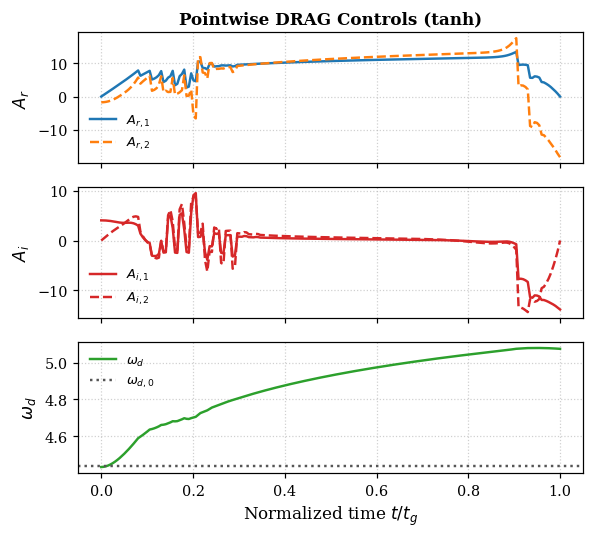

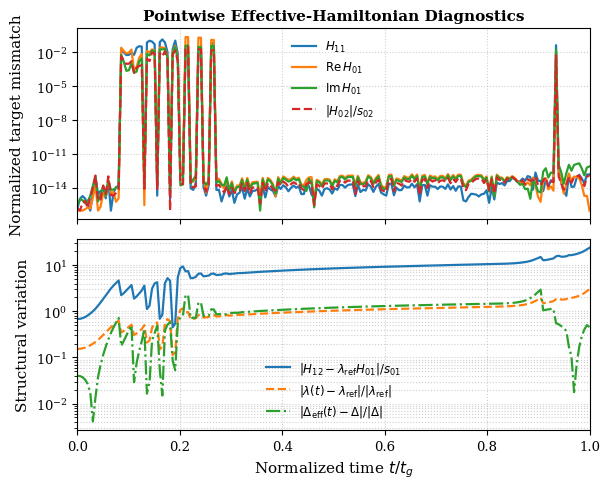

In [7]:
result.plot_pulse_shapes()
result.plot_errors()
plt.show()


 ## 7. Propagation of the idealized DRAG target



 This propagation tests the generated three-level target independently of the

 Floquet realization. The result provides a useful reference for separating an

 imperfect target from an imperfect mapping of the physical controls.


Pure time-dependent DRAG target:
Population fidelity:           0.3811531308
Population infidelity:         6.188e-01
Mean final leakage:            4.597e-01


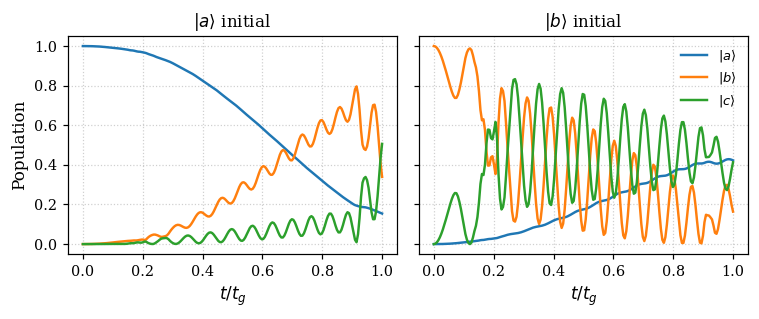

In [8]:
result.simulate_drag_target()


In [9]:
# Replot the stored target dynamics without repeating the propagation.
# result.plot_drag_dynamics()
# plt.show()


 ## 8. Full Floquet reconstruction



 The cached effective Hamiltonian is propagated as a reference. In parallel,

 $H_{\mathrm{eff}}(t)$ is recalculated explicitly from the continuous pulse and

 its spline derivatives. The resulting propagator is mapped back with

 $M(t)U_{\mathrm{eff}}(t)M^{-1}(0)$, normalized in the full Hilbert space, and

 only then projected onto the resonant subspace.

In [10]:
def compute_full_floquet(result, full_rH=2, full_rW=2, include_geometric=True, include_g_corr=True, include_micromotion=True):
    c, s = result.c, result.s
    d_res, D = len(s.resonances), len(s.E_array)
    res_indices, kref = list(s.resonances), min(s.resonances)
    splines = (
        result.wd_func, result.Ar_func, result.Ai_func,
        result.Ar2_func, result.Ai2_func,
    )[:result.n_controls]

    def floquet_data(t, compute_heff=True):
        controls = np.array([float(f(t)) for f in splines])
        derivatives = np.array([float(f(t, 1)) for f in splines])
        wd, Ar1, Ai1, Ar2, Ai2 = result.unpack_controls(controls)
        dwd, dAr1, dAi1, dAr2, dAi2 = result.unpack_controls(derivatives)
        A1, dA1 = Ar1 + 1j * Ai1, dAr1 + 1j * dAi1

        if c.use_second_harmonic:
            A = np.array([A1, Ar2 + 1j * Ai2])
            dA = np.array([dA1, dAr2 + 1j * dAi2])
            V = np.array([s.V1_dressed_array, s.V1_dressed_array])
        else:
            A, dA, V = A1, dA1, s.V1_dressed_array

        W = W_Floquet_elements_fast(
            full_rW, wd, s.resonances, s.E_array, V,
            A=A, V0=None, analytics=False, verbose=False,
        )
        if not compute_heff:
            return wd, W, None

        H = Heff_Floquet_total_matrix_summed(
            full_rH, wd, A, s.resonances, s.E_array, V,
            V0=None, ref_state=getattr(s, "ref_state", None),
            dwd=dwd, dA=dA, t=t, analytics=False, rW=full_rW,
            include_geometric=include_geometric, include_micromotion=include_micromotion,
            include_g_correction=include_g_corr, W=W, verbose=False,
        )
        return wd, W, np.asarray(H, dtype=complex)

    def frame_map(wd, W, t):
        M = np.zeros((D, d_res), dtype=complex)
        for r in range(full_rW + 1):
            for l in range(D):
                for column, state in enumerate(s.resonances):
                    for p, (coefficient, _, _) in W[r, l, state].items():
                        M[l, column] += np.exp(
                            -1j * (s.E_array[kref] + p * wd) * t
                        ) * coefficient
        return M

    def project(U_eff, M, M_inv_0):
        columns = (M @ U_eff @ M_inv_0)[:, res_indices]
        norms = np.linalg.norm(columns, axis=0)
        if np.any(norms < 1e-14):
            raise ValueError(f"Floquet columns with vanishing norm: {norms}")
        return (columns / norms[np.newaxis, :])[res_indices, :]

    wd0, W0, _ = floquet_data(result.tlist[0], compute_heff=False)
    M_inv_0 = np.zeros((d_res, D), dtype=complex)
    for r in range(full_rW + 1):
        for l in range(D):
            for row, state in enumerate(s.resonances):
                for _, (coefficient, _, _) in W0[r, l, state].items():
                    M_inv_0[row, l] += np.conjugate(coefficient)

    H_cached = CubicSpline(result.tlist, result.H_eff_values, axis=0)
    shape = (len(result.tlist), d_res, d_res)
    U_cached_values = np.empty(shape, dtype=complex)
    U_explicit_values = np.empty(shape, dtype=complex)
    U_floquet_values = np.empty(shape, dtype=complex)
    U_cached = U_explicit = np.eye(d_res, dtype=complex)
    U_cached_values[0] = U_cached
    U_explicit_values[0] = U_explicit
    U_floquet_values[0] = project(U_explicit, frame_map(wd0, W0, 0.0), M_inv_0)

    for k in tqdm(range(len(result.tlist) - 1), desc="Full Floquet propagation"):
        t0, t1 = result.tlist[k:k + 2]
        t_mid, dt = 0.5 * (t0 + t1), t1 - t0
        U_cached = expm(-1j * H_cached(t_mid) * dt) @ U_cached
        _, _, H_explicit = floquet_data(t_mid)
        U_explicit = expm(-1j * H_explicit * dt) @ U_explicit
        wd, W, _ = floquet_data(t1, compute_heff=False)

        U_cached_values[k + 1] = U_cached
        U_explicit_values[k + 1] = U_explicit
        U_floquet_values[k + 1] = project(
            U_explicit, frame_map(wd, W, t1), M_inv_0
        )

    output = {
        "U_cached_values": U_cached_values,
        "U_explicit_values": U_explicit_values,
        "U_floquet_values": U_floquet_values,
        "I_cached": infid_population(U_cached_values[-1]),
        "I_explicit": infid_population(U_explicit_values[-1]),
        "I_floquet": infid_population(U_floquet_values[-1]),
    }
    result.floquet_result = output
    return output


floquet_result = compute_full_floquet(result, full_rH=2, full_rW=1,
                                      include_micromotion=True, include_g_corr=False, include_geometric=False)
print(f"Cached effective-space infidelity:   {floquet_result['I_cached']:.3e}")
print(f"Explicit effective-space infidelity: {floquet_result['I_explicit']:.3e}")
print(f"Transformed Floquet infidelity:      {floquet_result['I_floquet']:.3e}")


Full Floquet propagation:   0%|          | 0/199 [00:00<?, ?it/s]

Cached effective-space infidelity:   3.151e-01
Explicit effective-space infidelity: 3.091e-01
Transformed Floquet infidelity:      3.845e-01


 ## 9. Floquet dynamics plot



 The colored curves show the fully transformed Floquet prediction. The cached

 effective-space trajectories are retained as black dashed references. Editing

 this cell does not trigger a new Floquet calculation.

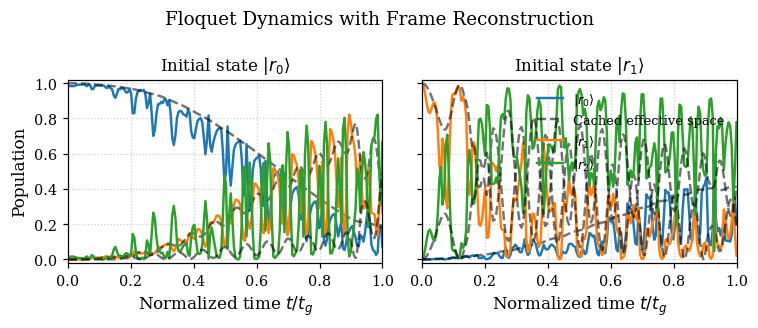

In [11]:
time = result.tlist / result.c.tg
U_floquet_values = floquet_result["U_floquet_values"]
U_cached_values = floquet_result["U_cached_values"]
d_res = U_floquet_values.shape[1]
labels = [rf"$|r_{j}\rangle$" for j in range(d_res)]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0), sharey=True, dpi=110)
for initial, ax in enumerate(axes):
    transformed = np.abs(U_floquet_values[:, :, initial])**2
    cached = np.abs(U_cached_values[:, :, initial])**2
    for state, label in enumerate(labels):
        if transformed[:, state].max() > 1e-5:
            ax.plot(time, transformed[:, state], label=label)
        if cached[:, state].max() > 1e-5:
            ax.plot(
                time, cached[:, state], "k--", alpha=0.55,
                label="Cached effective space" if state == 0 else None,
            )
    ax.set_title(f"Initial state {labels[initial]}")
    ax.set(xlabel=r"Normalized time $t/t_g$", xlim=(0, 1), ylim=(-0.02, 1.02))
    ax.grid(True, linestyle=":", alpha=0.6)

axes[0].set_ylabel("Population")
axes[1].legend(frameon=False)
fig.suptitle("Floquet Dynamics with Frame Reconstruction")
fig.tight_layout()
plt.show()


 ## 10. Direct full-system propagation



 This is another expensive stage and is therefore kept separate from its plot.

 The final computational propagator and complete population trajectories are

 stored in `direct_result`.

In [12]:
drive = result.build_drive_signal()
tlist_direct = np.linspace(
    0.0, result.c.tg,
    max(1001, int(result.c.tg * result.c.steps_per_ns) + 1),
)
comp_states = [result.s.E_states[i] for i in result.s.comp_indices]
U_direct = np.zeros((len(comp_states), len(comp_states)), dtype=complex)

for column, psi0 in enumerate(tqdm(comp_states, desc="Direct simulation")):
    evolution = sesolve(
        [result.s.H0, [result.s.V1, drive]], psi0, tlist_direct,
        options={"nsteps": 100000},
    )
    U_direct[:, column] = [state.overlap(evolution.states[-1]) for state in comp_states]

dynamics = sesolve(
    [result.s.H0, [result.s.V1, drive]],
    result.s.E_states[result.state_0], tlist_direct,
    options={"nsteps": 100000},
)
direct_populations = np.array([
    [abs(state.overlap(psi))**2 for psi in dynamics.states]
    for state in result.s.E_states
])

direct_result = {
    "U": U_direct,
    "infidelity": infid_population(U_direct),
    "tlist": tlist_direct,
    "populations": direct_populations,
}
result.direct_result = direct_result
print(f"Direct population infidelity: {direct_result['infidelity']:.3e}")


Direct simulation:   0%|          | 0/4 [00:00<?, ?it/s]

Direct population infidelity: 6.606e-01


 ## 11. Direct-dynamics plot



 This cell only reads the stored direct-simulation result and can therefore be

 reformatted freely without solving the Schrödinger equation again.

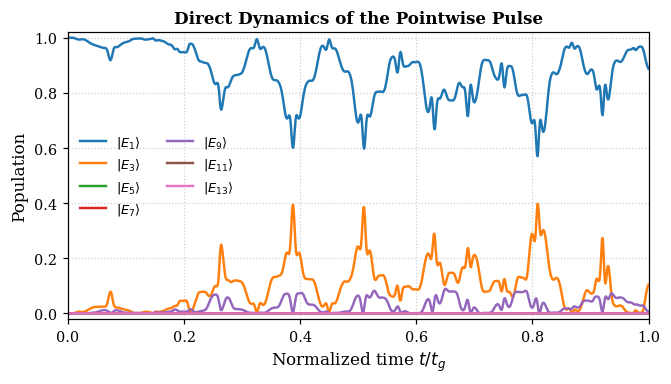

In [13]:
fig, ax = plt.subplots(figsize=(6.2, 3.6), dpi=110)
for index, population in enumerate(direct_result["populations"]):
    if population.max() > 1e-4:
        ax.plot(
            direct_result["tlist"] / result.c.tg,
            population,
            label=rf"$|E_{{{index}}}\rangle$",
        )

ax.set(
    xlabel=r"Normalized time $t/t_g$",
    ylabel="Population",
    xlim=(0, 1),
    ylim=(-0.02, 1.02),
)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(frameon=False, ncol=2)
ax.set_title("Direct Dynamics of the Pointwise Pulse", fontweight="bold")
fig.tight_layout()
plt.show()


 ## 12. Summary



 The final cell collects the three central predictions without performing any

 additional propagation.

In [14]:
print(f"DRAG-target infidelity:         {result.I_drag:.3e}")
print(f"Cached effective infidelity:    {floquet_result['I_cached']:.3e}")
print(f"Explicit effective infidelity:  {floquet_result['I_explicit']:.3e}")
print(f"Transformed Floquet infidelity: {floquet_result['I_floquet']:.3e}")
print(f"Direct full-system infidelity:  {direct_result['infidelity']:.3e}")


DRAG-target infidelity:         6.188e-01
Cached effective infidelity:    3.151e-01
Explicit effective infidelity:  3.091e-01
Transformed Floquet infidelity: 3.845e-01
Direct full-system infidelity:  6.606e-01


In [15]:
# Direct numerical optimization of wd_offset, A1 scale and A2 scale.
# Each amplitude scale multiplies both quadratures of its harmonic.

from scipy.optimize import differential_evolution
from qutip import sesolve
from pulse_optimization import infid_population

if not result.c.use_second_harmonic:
    raise ValueError("This optimization requires use_second_harmonic=True.")

parameter_names = ["wd_offset", "amp1_scale", "amp2_scale"]
parameter_bounds = [
    (-0.2, 0.2),   # wd_offset
    (0.8, 1.5),    # A1 scale
    (-3.0, 3.0),   # A2 scale
]

comp_states = [result.s.E_states[i] for i in result.s.comp_indices]
tspan = np.array([0.0, result.c.tg])
objective_cache = {}

def direct_propagator(parameters):
    wd_offset, amp1_scale, amp2_scale = parameters

    def drive(t, args=None):
        wd = float(result.wd_func(t)) + wd_offset
        phi = wd * t

        q1 = (
            float(result.Ar_func(t)) * np.cos(phi)
            + float(result.Ai_func(t)) * np.sin(phi)
        )
        q2 = (
            float(result.Ar2_func(t)) * np.cos(2.0 * phi)
            + float(result.Ai2_func(t)) * np.sin(2.0 * phi)
        )
        return amp1_scale * q1 + amp2_scale * q2

    U = np.zeros((len(comp_states), len(comp_states)), dtype=complex)

    for column, psi0 in enumerate(comp_states):
        evolution = sesolve(
            [result.s.H0, [result.s.V1, drive]],
            psi0,
            tspan,
            options={"nsteps": 100000},
        )
        psi_final = evolution.states[-1]
        U[:, column] = [state.overlap(psi_final) for state in comp_states]

    return U

def iteration_callback(xk, convergence=None):
    wd_off, a1, a2 = xk
    # Berechnet den aktuellen Bestwert aus dem Cache
    current_best_key = tuple(np.round(xk, 12))
    current_cost = objective_cache.get(current_best_key, "N/A")
    
    if isinstance(current_cost, float):
        print(f"[Generation] Best Infid: {current_cost:.6e} | wd_off: {wd_off:.6f}, A1: {a1:.6f}, A2: {a2:.6f}")
    else:
        print(f"[Generation] Best Params: wd_off: {wd_off:.6f}, A1: {a1:.6f}, A2: {a2:.6f}")

def objective(parameters):
    key = tuple(np.round(parameters, 12))

    if key not in objective_cache:
        objective_cache[key] = infid_population(
            direct_propagator(parameters)
        )

    return objective_cache[key]

direct_opt = differential_evolution(
    objective,
    bounds=parameter_bounds,
    x0=np.array([0.0, 1.0, 1.0]),strategy="best1bin",popsize=6,maxiter=30,tol=1e-7,atol=1e-10,polish=True,seed=1,workers=1,updating="immediate",disp=True,
    callback=iteration_callback,
)

wd_offset_opt, amp1_scale_opt, amp2_scale_opt = direct_opt.x
U_direct_opt = direct_propagator(direct_opt.x)
I_pop_direct_opt = infid_population(U_direct_opt)

result.wd_offset_opt = wd_offset_opt
result.amp1_scale_opt = amp1_scale_opt
result.amp2_scale_opt = amp2_scale_opt
result.U_direct_opt = U_direct_opt
result.I_pop_direct_opt = I_pop_direct_opt

def optimized_drive_signal(t, args=None):
    wd = float(result.wd_func(t)) + wd_offset_opt
    phi = wd * t

    q1 = (
        float(result.Ar_func(t)) * np.cos(phi)
        + float(result.Ai_func(t)) * np.sin(phi)
    )
    q2 = (
        float(result.Ar2_func(t)) * np.cos(2.0 * phi)
        + float(result.Ai2_func(t)) * np.sin(2.0 * phi)
    )
    return amp1_scale_opt * q1 + amp2_scale_opt * q2

print("\nOptimized direct pulse")
print(f"wd_offset:  {wd_offset_opt:.12g}")
print(f"amp1_scale: {amp1_scale_opt:.12g}")
print(f"amp2_scale: {amp2_scale_opt:.12g}")
print(f"Population fidelity:   {1.0 - I_pop_direct_opt:.10f}")
print(f"Population infidelity: {I_pop_direct_opt:.3e}")

differential_evolution step 1: f(x)= 0.5279424944501698
[Generation] Best Infid: 5.279425e-01 | wd_off: 0.075365, A1: 1.427279, A2: 0.948077


ValueError: Function to integrate must not return a tuple.

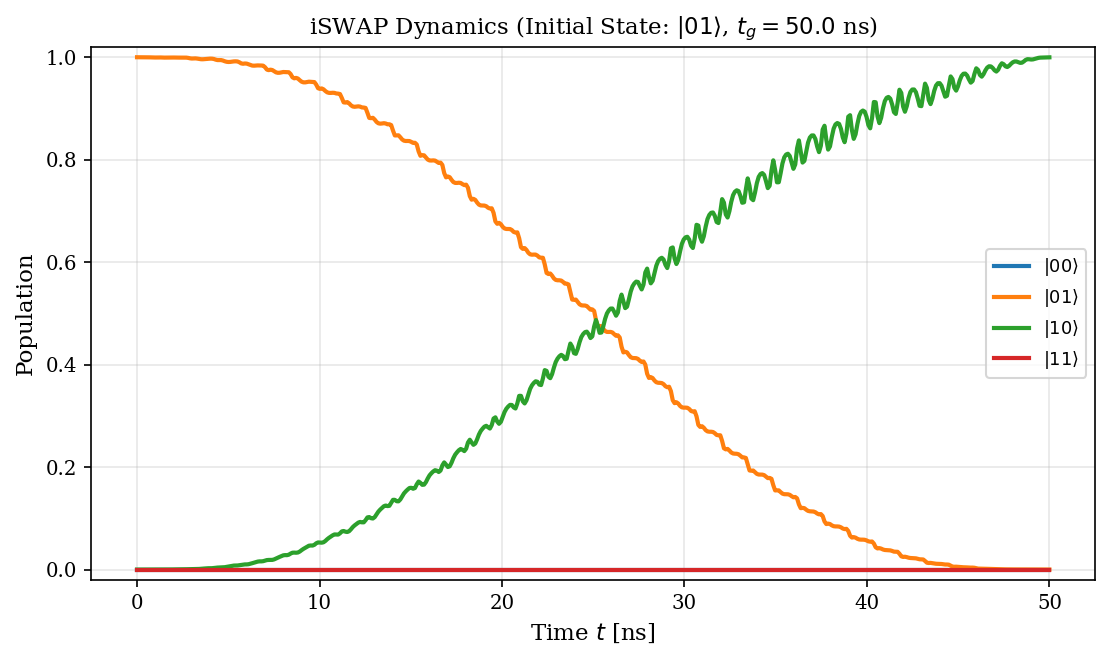

              OPTIMIZATION SUMMARY               
Gate duration (tg) : 50.0 ns
Optimal wd_offset  : -0.03309306 GHz
Optimal amp1_scale : 0.86536558
Optimal amp2_scale : 1.31243257
Final Infidelity   : 1.0213e-04
Final Fidelity     : 99.989787 %


In [ ]:
import matplotlib.pyplot as plt

# 1. Zeitgitter für Trajektorien
t_plot = np.linspace(0, result.c.tg, 500)

# 2. Startzustand auf |01> setzen (Index 1 der computational states)
init_idx = 1
psi0_plot = comp_states[init_idx]

res_plot = sesolve(
    [result.s.H0, [result.s.V1, optimized_drive_signal]],
    psi0_plot,
    t_plot,
    options={"nsteps": 100000},
)

# 3. Populationen berechnen: P_i(t) = |<psi_i | psi(t)>|^2
num_comp = len(comp_states)
pops = np.zeros((num_comp, len(t_plot)))
for idx, state in enumerate(comp_states):
    pops[idx, :] = [abs(state.overlap(psi)) ** 2 for psi in res_plot.states]

# 4. Binäre Zustands-Labels erzeugen (|00>, |01>, |10>, |11>)
bit_len = int(np.log2(num_comp)) if num_comp > 1 else 1
state_labels = [
    rf"$|{format(i, f'0{bit_len}b')}\rangle$" for i in range(num_comp)
]

# 5. Dynamics Plot
fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=150)
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

for idx in range(num_comp):
    ax.plot(
        t_plot,
        pops[idx, :],
        label=state_labels[idx],
        color=colors[idx % len(colors)],
        lw=2.0,
    )

ax.set_xlabel(r"Time $t$ [ns]")
ax.set_ylabel("Population")
ax.set_title(
    rf"iSWAP Dynamics (Initial State: {state_labels[init_idx]}, $t_g = {result.c.tg}$ ns)"
)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="center right", frameon=True)

plt.tight_layout()
plt.show()

# 6. Summary
print("==================================================")
print("              OPTIMIZATION SUMMARY               ")
print("==================================================")
print(f"Gate duration (tg) : {result.c.tg} ns")
print(f"Optimal wd_offset  : {wd_offset_opt:.8f} GHz")
print(f"Optimal amp1_scale : {amp1_scale_opt:.8f}")
print(f"Optimal amp2_scale : {amp2_scale_opt:.8f}")
print(f"Final Infidelity   : {I_pop_direct_opt:.4e}")
print(f"Final Fidelity     : {(1.0 - I_pop_direct_opt) * 100:.6f} %")
print("==================================================")